In [21]:
import matplotlib.pyplot as plt
import numpy as np
from synthetic_data import distributions, generate_ground_truths, generate_sample_csv

In [22]:
def owens_bozic_model(y, t, params):
    T, E, C, M = y
    a, b, dE, dC, g, jE, jC, K, k, l, mE, mC, qE, qC, s, KT, KE, KC, gamma = params

    C = max(C, 0)
    E = max(E, 0)

    tol = 1e-10

    if T < tol:
        DE = 0
    elif E < T:
        DE = dE * (E / T)**l / (s + (E / T)**l) * T
    else:
        DE = dE * (1 - s / (s + (T/E)**(-l))) * T

    if T < tol:
        DC = 0
    elif C < T:
        DC = dC * (C / T)**l / (s + (C / T)**l) * T
    else:
        DC = dC * (1 - s / (s + (T/C)**(-l))) * T

    dT_dt = a * T * (1 - b * T) - DE - DC - KT * (1 - np.exp(-M)) * T
    dE_dt = g - mE * E - jE * np.log((E + C) / K) * (DE**2) / (k + DE**2) * E  - qE * E * T - KE * (1 - np.exp(-M)) * E
    dC_dt = - mC * C - jC * np.log((E + C) / K) * (DC**2) / (k + DC**2) * C - qC * C * T - KC * (1 - np.exp(-M)) * C
    dM_dt = - gamma * M

    return [dT_dt, dE_dt, dC_dt, dM_dt]

In [23]:
def csv_and_indiv_param_vals(
    param: str,
    noise_level: float,
    n_obs: int,
    param_seed: int,
    noise_seed: int,
    csv_filename: str | None = None,
    n_indivs=10,
    max_day_number=100,
):
    f_pop = 1.0  # scale factor for pop param std

    partial_pop_param_info = [
        ("a", 3.3e-1, 0.6 * f_pop, distributions["lognormal"]),
        ("b", 2.26e-11, 5.1 * f_pop, distributions["lognormal"]),
        ("dE", 3.17, 0.6 * f_pop, distributions["lognormal"]),
        ("dC", 2.25, 0.01 * f_pop, distributions["lognormal"]),
        ("g", 1.03e4, 1.7 * f_pop, distributions["lognormal"]),
        ("jE", 1.56e-2, 0.75 * f_pop, distributions["lognormal"]),
        ("jC", 3.46e-1, 0.75 * f_pop, distributions["lognormal"]),
        ("K", 5.21e8, 1.5 * f_pop, distributions["lognormal"]),
        ("k", 8.67e6, 3.0 * f_pop, distributions["lognormal"]),
        ("l", 1.418, 0.013 * f_pop, distributions["lognormal"]),
        ("mE", 1.76e-2, 0.76 * f_pop, distributions["lognormal"]),
        ("mC", 0.293, 0.01 * f_pop, distributions["lognormal"]),
        ("qE", 1.28e-10, 1.35 * f_pop, distributions["lognormal"]),
        ("qC", 2.14e-10, 2.6 * f_pop, distributions["lognormal"]),
        ("s", 3.02e-1, 0.17 * f_pop, distributions["lognormal"]),
        ("KT", 0.7, 0.01 * f_pop, distributions["lognormal"]),
        ("KE", 0.6, 0.01 * f_pop, distributions["lognormal"]),
        ("KC", 0.6, 0.01 * f_pop, distributions["lognormal"]),
        ("gamma", 0.9, 0.01 * f_pop, distributions["lognormal"]),
    ]

    param_idx = -1
    for i, x in enumerate(partial_pop_param_info):
        if x[0] == param:
            param_idx = i
            break

    if param_idx == -1:
        raise ValueError(f"unknown param {param}")

    pop_param_info = [(*x, x[0] != param) for x in partial_pop_param_info]
    obs_var_info = [
        (
            "T",
            1.58e9,
            1.5,
            distributions["normal"],
            "combined1",
            0,
            noise_level,
            1,
            distributions["normal"],
            "log10",
            True,
        ),
        (
            "E",
            4e5,
            0.01,
            distributions["normal"],
            "combined1",
            0,
            noise_level,
            1,
            distributions["normal"],
            "log10",
            True,
        ),
        (
            "C",
            6.3e7,
            2.0,
            distributions["normal"],
            "combined1",
            0,
            noise_level,
            1,
            distributions["normal"],
            "log10",
            True,
        ),
        (
            "M",
            6.0,
            0.2,
            distributions["normal"],
            "combined1",
            0,
            noise_level,
            1,
            distributions["normal"],
            "log10",
            True,
        ),
    ]
    obs_times_all = [
        [max_day_number * i // n_obs for i in range(1, n_obs + 1)]
        for _ in range(n_indivs)
    ]
    sampled_params_all, initial_conditions_all, _, _, _ = generate_sample_csv(
        csv_filename or "owens_bozic_noiseexp",
        owens_bozic_model,
        pop_param_info,
        obs_var_info,
        n_indivs,
        n_obs,
        max_day_number,
        obs_times_all=obs_times_all,
        param_seed=param_seed,
        noise_seed=noise_seed,
    )

    return (
        [x[param_idx] for x in sampled_params_all],
        sampled_params_all,
        initial_conditions_all,
        param_idx,
    )


def csv_and_param_subset_vals(
    params: list[str],
    noise_level: float,
    n_obs: int,
    param_seed: int,
    noise_seed: int,
    csv_filename: str | None = None,
    n_indivs=10,
    max_day_number=100,
):
    f_pop = 1.0  # scale factor for pop param std

    partial_pop_param_info = [
        ("a", 3.3e-1, 0.6 * f_pop, distributions["lognormal"]),
        ("b", 2.26e-11, 5.1 * f_pop, distributions["lognormal"]),
        ("dE", 3.17, 0.6 * f_pop, distributions["lognormal"]),
        ("dC", 2.25, 0.01 * f_pop, distributions["lognormal"]),
        ("g", 1.03e4, 1.7 * f_pop, distributions["lognormal"]),
        ("jE", 1.56e-2, 0.75 * f_pop, distributions["lognormal"]),
        ("jC", 3.46e-1, 0.75 * f_pop, distributions["lognormal"]),
        ("K", 5.21e8, 1.5 * f_pop, distributions["lognormal"]),
        ("k", 8.67e6, 3.0 * f_pop, distributions["lognormal"]),
        ("l", 1.418, 0.013 * f_pop, distributions["lognormal"]),
        ("mE", 1.76e-2, 0.76 * f_pop, distributions["lognormal"]),
        ("mC", 0.293, 0.01 * f_pop, distributions["lognormal"]),
        ("qE", 1.28e-10, 1.35 * f_pop, distributions["lognormal"]),
        ("qC", 2.14e-10, 2.6 * f_pop, distributions["lognormal"]),
        ("s", 3.02e-1, 0.17 * f_pop, distributions["lognormal"]),
        ("KT", 0.7, 0.01 * f_pop, distributions["lognormal"]),
        ("KE", 0.6, 0.01 * f_pop, distributions["lognormal"]),
        ("KC", 0.6, 0.01 * f_pop, distributions["lognormal"]),
        ("gamma", 0.9, 0.01 * f_pop, distributions["lognormal"]),
    ]

    param_idxs = [-1, -1]
    for j, param in enumerate(params):
        for i, x in enumerate(partial_pop_param_info):
            if x[0] == param:
                param_idxs[j] = i
                break

        if param_idxs[j] == -1:
            raise ValueError(f"unknown param {param}")
    print(param_idxs)

    pop_param_info = [(*x, x[0] not in params) for x in partial_pop_param_info]
    obs_var_info = [
        (
            "T",
            1.58e9,
            1.5,
            distributions["normal"],
            "combined1",
            0,
            noise_level,
            1,
            distributions["normal"],
            "log10",
            True,
        ),
        (
            "E",
            4e5,
            0.01,
            distributions["normal"],
            "combined1",
            0,
            noise_level,
            1,
            distributions["normal"],
            "log10",
            True,
        ),
        (
            "C",
            6.3e7,
            2.0,
            distributions["normal"],
            "combined1",
            0,
            noise_level,
            1,
            distributions["normal"],
            "log10",
            True,
        ),
        (
            "M",
            6.0,
            0.2,
            distributions["normal"],
            "combined1",
            0,
            noise_level,
            1,
            distributions["normal"],
            "log10",
            True,
        ),
    ]
    obs_times_all = [
        [max_day_number * i // n_obs for i in range(1, n_obs + 1)]
        for _ in range(n_indivs)
    ]
    sampled_params_all, initial_conditions_all, _, _, _ = generate_sample_csv(
        csv_filename or "owens_bozic_noiseexp",
        owens_bozic_model,
        pop_param_info,
        obs_var_info,
        n_indivs,
        n_obs,
        max_day_number,
        obs_times_all=obs_times_all,
        param_seed=param_seed,
        noise_seed=noise_seed,
    )

    return (
        [[x[param_idx] for param_idx in param_idxs] for x in sampled_params_all],
        sampled_params_all,
        initial_conditions_all,
        param_idxs,
    )


In [24]:
def get_info_for_ground_truths(
    param: str, noise_level: float, param_seed: int, noise_seed: int
):
    _, sampled_params_all, initial_conditions_all, param_idxs = csv_and_indiv_param_vals(
        param, noise_level, 1, param_seed, noise_seed, n_indivs=1
    )
    return sampled_params_all, initial_conditions_all, param_idxs


In [25]:
sampled_params_all, initial_conditions_all, param_idxs = get_info_for_ground_truths(
    "a", 0.25, 9, 69420
)
ground_truths = generate_ground_truths(
    owens_bozic_model, sampled_params_all, initial_conditions_all, 
)

TypeError: generate_ground_truths() missing 1 required positional argument: 'obs_times_all'

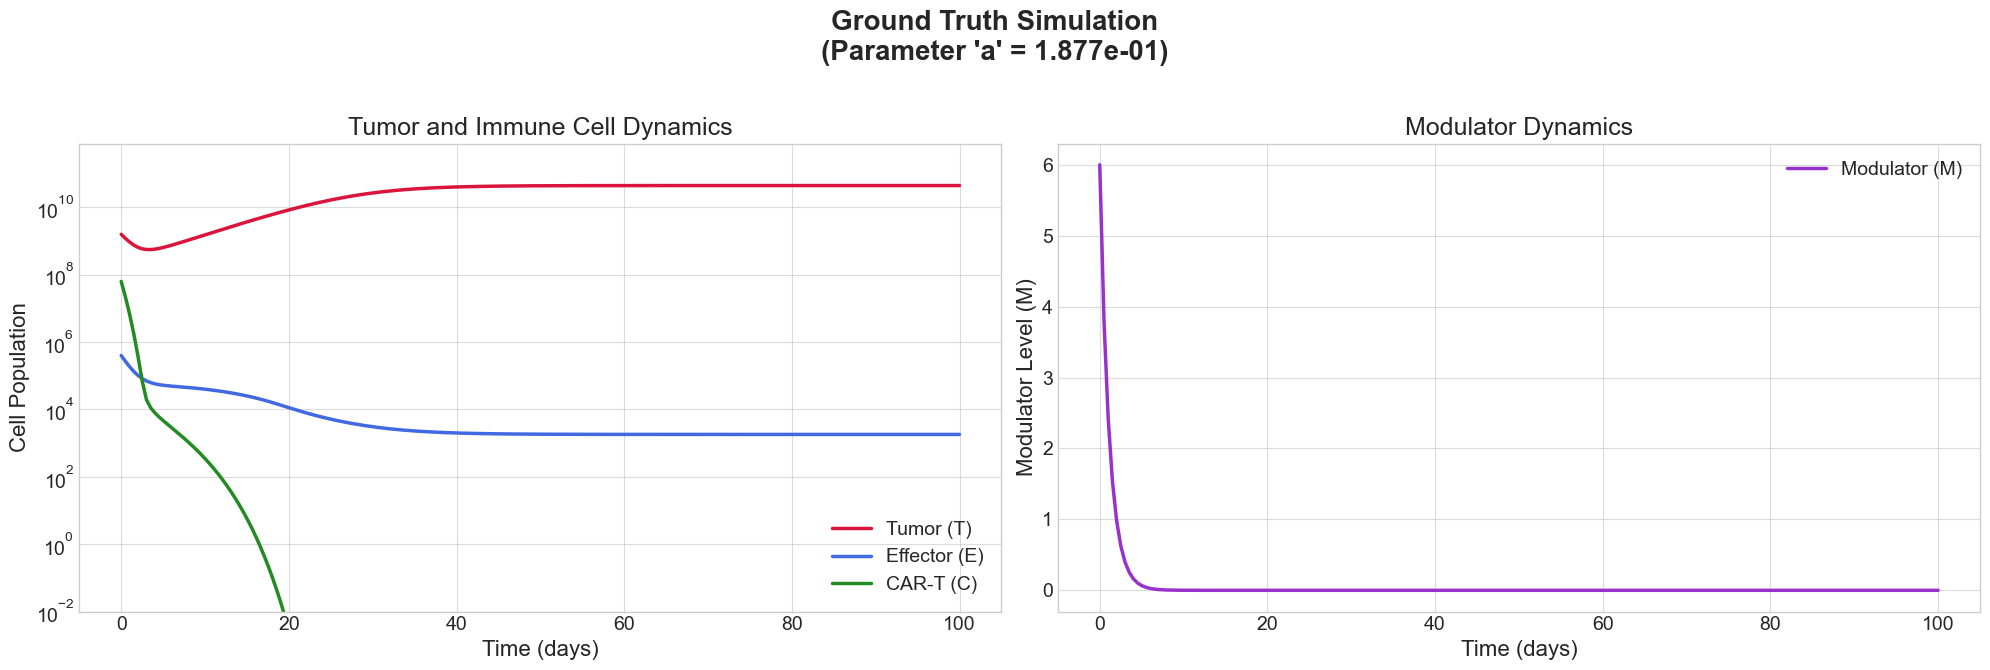

In [26]:
import matplotlib.pyplot as plt
import numpy as np
# Assuming synthetic_data.py is in the same directory or accessible in PYTHONPATH
from synthetic_data import distributions, generate_ground_truths, generate_sample_csv 
# If synthetic_data.py content is in the same notebook, the above import is not needed,
# and you'd directly use the functions defined in Block 1.
# For this example, I'll assume the functions from Block 1 are directly available.

def owens_bozic_model(y, t, params):
    T, E, C, M = y
    # Unpack all 19 parameters, ensure order matches `partial_pop_param_info`
    a, b, dE, dC, g, jE, jC, K, k, l, mE, mC, qE, qC, s, KT, KE, KC, gamma = params

    # Ensure non-negative cell counts for stability if model can go negative
    C = max(C, 0.0) # Using 0.0 for float comparison
    E = max(E, 0.0)
    # T can be very low but typically not forced positive in this way unless solver issues

    tol = 1e-9 # Tolerance for division by zero or very small T

    # Simplified kill terms based on Monolix example structure (often uses T directly)
    # Original logic was a bit complex and might lead to issues if T is very small.
    # Standard Holling type II or similar: (d * E * T) / (s + T) or (d * E * T) / (s_scaled_by_E + T)
    # Your model uses a ratio-dependent form E/T or C/T.

    # DE term: Killing of T by E
    if T < tol or E < tol: # If no tumor or no effectors, no killing by E
        DE = 0.0
    else:
        ratio_ET = E / T
        DE = dE * (ratio_ET**l) / (s + ratio_ET**l) * T 
        # This can be written as dE * E^l / (s * T^l + E^l) * T if simplified

    # DC term: Killing of T by C
    if T < tol or C < tol: # If no tumor or no CAR-T, no killing by C
        DC = 0.0
    else:
        ratio_CT = C / T
        DC = dC * (ratio_CT**l) / (s + ratio_CT**l) * T

    dT_dt = a * T * (1 - b * T) - DE - DC - KT * (1 - np.exp(-M)) * T
    
    # Expansion terms J_E * log((E+C)/K) * (DE^2)/(k+DE^2) * E can be problematic if E+C is very small or K is such that log is negative.
    # K is a carrying capacity, so (E+C)/K should ideally be around 1 or less for log to be negative (suppression) or near 0.
    # If (E+C)/K > 1, log is positive, leading to expansion. If < 1, log is negative (decay).
    # A common alternative for expansion term is Michaelis-Menten like: jE * Stimulus * E / (Km_exp + Stimulus)
    # For now, using your provided structure, but with safeguards.
    
    log_factor_EC = 0.0
    if E + C > tol and K > tol : # Avoid log(0) or log of negative if K is not well-defined
        log_factor_EC = np.log(max(tol, (E + C)) / K) # max(tol, E+C) to avoid log(0)
    
    stimulus_E = DE # Assuming DE is the stimulus for E cell expansion
    expansion_E_factor = (stimulus_E**2) / (k + stimulus_E**2) if k + stimulus_E**2 > tol else 0

    stimulus_C = DC # Assuming DC is the stimulus for C cell expansion
    expansion_C_factor = (stimulus_C**2) / (k + stimulus_C**2) if k + stimulus_C**2 > tol else 0

    dE_dt = g - mE * E + jE * log_factor_EC * expansion_E_factor * E  - qE * E * T - KE * (1 - np.exp(-M)) * E
    dC_dt =       - mC * C + jC * log_factor_EC * expansion_C_factor * C  - qC * C * T - KC * (1 - np.exp(-M)) * C
    dM_dt = - gamma * M

    return [dT_dt, dE_dt, dC_dt, dM_dt]

def csv_and_indiv_param_vals( # This function seems mostly for setting up generate_sample_csv
    param_to_fix: str, # param_to_fix implies other params are NOT fixed (varied around pop mean)
    noise_level: float,
    n_obs_per_indiv: int, # Renamed for clarity
    param_sampling_seed: int, # Renamed
    noise_addition_seed: int, # Renamed
    csv_filename_out: str | None = None, # Renamed
    n_indivs_to_generate=10, # Renamed
    max_day_for_obs=100, # Renamed
):
    f_pop = 1.0  # scale factor for pop param std

    # Parameter definitions: name, pop_mean, pop_std_factor, distribution_obj
    partial_pop_param_info_list = [ # Renamed
        ("a", 3.3e-1, 0.6 * f_pop, distributions["lognormal"]),
        ("b", 2.26e-11, 5.1 * f_pop, distributions["lognormal"]),
        ("dE", 3.17, 0.6 * f_pop, distributions["lognormal"]),
        ("dC", 2.25, 0.01 * f_pop, distributions["lognormal"]), # dC std was very small, might be effectively fixed
        ("g", 1.03e4, 1.7 * f_pop, distributions["lognormal"]),
        ("jE", 1.56e-2, 0.75 * f_pop, distributions["lognormal"]),
        ("jC", 3.46e-1, 0.75 * f_pop, distributions["lognormal"]),
        ("K", 5.21e8, 1.5 * f_pop, distributions["lognormal"]),
        ("k", 8.67e6, 3.0 * f_pop, distributions["lognormal"]),
        ("l", 1.418, 0.013 * f_pop, distributions["lognormal"]), # l std was very small
        ("mE", 1.76e-2, 0.76 * f_pop, distributions["lognormal"]),
        ("mC", 0.293, 0.01 * f_pop, distributions["lognormal"]), # mC std was very small
        ("qE", 1.28e-10, 1.35 * f_pop, distributions["lognormal"]),
        ("qC", 2.14e-10, 2.6 * f_pop, distributions["lognormal"]),
        ("s", 3.02e-1, 0.17 * f_pop, distributions["lognormal"]),
        ("KT", 0.7, 0.01 * f_pop, distributions["lognormal"]), # KT, KE, KC stds very small
        ("KE", 0.6, 0.01 * f_pop, distributions["lognormal"]),
        ("KC", 0.6, 0.01 * f_pop, distributions["lognormal"]),
        ("gamma", 0.9, 0.01 * f_pop, distributions["lognormal"]), # gamma std very small
    ]

    param_idx_of_interest = -1
    for i, x_info in enumerate(partial_pop_param_info_list):
        if x_info[0] == param_to_fix:
            param_idx_of_interest = i
            break
    if param_idx_of_interest == -1:
        raise ValueError(f"Unknown parameter to fix/track: {param_to_fix}")

    # is_fixed: True if param name is NOT param_to_fix (meaning param_to_fix is varied, others fixed to pop mean)
    # This seems reversed from prompt's "is_fixed sets stdev to 0".
    # Let's assume user wants: param_to_fix has its given pop_std, others are fixed (std=0)
    # The last element of pop_param_info tuple is `is_fixed`.
    # If `is_fixed` is True, `generate_sample_csv` should use std=0 for that param.
    # So, a param is fixed IF ITS NAME IS NOT `param_to_fix`.
    pop_param_info_tuples = [(*x_info, x_info[0] != param_to_fix) for x_info in partial_pop_param_info_list]
    
    obs_var_info_tuples = [ # Renamed
        ("T",1.58e9,1.5,distributions["normal"],"combined1",0,noise_level,1,distributions["normal"],"log10",True),
        ("E",4e5,0.01,distributions["normal"],"combined1",0,noise_level,1,distributions["normal"],"log10",True),
        ("C",6.3e7,2.0,distributions["normal"],"combined1",0,noise_level,1,distributions["normal"],"log10",True),
        ("M",6.0,0.2,distributions["normal"],"combined1",0,noise_level,1,distributions["normal"],"log10",True),
    ]
    
    # This function is called by get_info_for_ground_truths with n_indivs_to_generate=1
    # and n_obs_per_indiv=1. The obs_times_all will be generated inside generate_sample_csv
    # if not provided here. Since we are only interested in the sampled parameters and initial conditions
    # for a single individual for the ground truth plot, the exact obs_times for *this* call
    # are less critical than the ones we'll use for plotting later.
    # However, to be consistent, generate_sample_csv will create obs_times if obs_times_all is None.

    # Let generate_sample_csv handle obs_times_all generation based on n_obs_per_indiv, etc.
    # when it's called with obs_times_all=None (the default)
    
    # generate_sample_csv returns:
    # sampled_model_params_all, sampled_initial_conditions_all, actual_obs_times_all, 
    # final_observations_all, output_data_dict
    s_params_all, s_init_conds_all, _, _, _ = generate_sample_csv(
        save_name = csv_filename_out or "temp_owens_bozic_sim", # Provide a default if None
        model = owens_bozic_model,
        pop_param_info = pop_param_info_tuples,
        obs_var_info = obs_var_info_tuples,
        n_indivs = n_indivs_to_generate,
        n_obs = n_obs_per_indiv,
        max_day_number = max_day_for_obs,
        obs_times_all = None, # Let generate_sample_csv create default times
        param_seed = param_sampling_seed,
        noise_seed = noise_addition_seed,
    )
    # This function expects to return parameters for the one parameter of interest
    # For ground truth plotting, we usually need the full parameter set for the individual.
    # The original return: [x[param_idx_of_interest] for x in s_params_all]
    # This returns a list of values for only the param_of_interest across all individuals.
    # If n_indivs_to_generate = 1, then s_params_all is [[p1, p2, ...]].
    # We need s_params_all itself.
    
    return (
        s_params_all, # Full list of parameter lists for all generated individuals
        s_init_conds_all, # Full list of initial condition lists
        param_idx_of_interest 
    )


# Function to get parameters for a single individual for ground truth plotting
def get_info_for_ground_truths(
    param_to_show_value_of: str, # The parameter whose value we want to display
    noise_level_sim: float, # Noise level used in simulation (less relevant for pure ground truth)
    param_seed_val: int, 
    noise_seed_val: int, # Seed for noise (less relevant for pure ground truth)
    max_day_for_plot: int = 100, 
    num_plot_points: int = 200 
):
    # Call csv_and_indiv_param_vals to get ONE set of sampled parameters and initial conditions
    # n_obs=1 here is just a placeholder for csv_and_indiv_param_vals, not for plotting times.
    sampled_params_list_for_indiv, initial_conditions_list_for_indiv, varied_param_idx = csv_and_indiv_param_vals(
        param_to_show_value_of, 
        noise_level_sim, 
        n_obs_per_indiv=10, # A more typical number of obs if CSV was generated
        param_sampling_seed=param_seed_val, 
        noise_addition_seed=noise_seed_val, 
        n_indivs_to_generate=1, # Generate for ONE individual
        max_day_for_obs=max_day_for_plot
    )
    
    # Create a dense time grid for plotting the ground truth ODE solution
    plotting_times_for_ode = np.linspace(0, max_day_for_plot, num_plot_points).tolist()
    # generate_ground_truths expects a list of lists for obs_times_all
    obs_times_for_gt_plotting = [plotting_times_for_ode] 

    # sampled_params_list_for_indiv is already [[p1,p2,...]]
    # initial_conditions_list_for_indiv is already [[ic1,ic2,...]]
    return sampled_params_list_for_indiv, initial_conditions_list_for_indiv, varied_param_idx, obs_times_for_gt_plotting

# New plotting function
def plot_simulation_results(times, data_T, data_E, data_C, data_M, 
                            main_plot_title="Owens-Bozic Model Simulation"):
    """
    Plots simulation results in a 1x2 subplot figure.
    Subplot 1: T, E, C cells (log scale)
    Subplot 2: M modulator
    """
    plt.style.use('seaborn-v0_8-whitegrid') 

    fig, axes = plt.subplots(1, 2, figsize=(20, 7)) # Increased figsize for bigger plots

    # --- Subplot 1: T, E, C cells ---
    axes[0].plot(times, data_T, label='Tumor (T)', color='crimson', linewidth=2.5)
    axes[0].plot(times, data_E, label='Effector (E)', color='royalblue', linewidth=2.5)
    axes[0].plot(times, data_C, label='CAR-T (C)', color='forestgreen', linewidth=2.5)
    
    axes[0].set_xlabel("Time (days)", fontsize=16)
    axes[0].set_ylabel("Cell Population", fontsize=16)
    axes[0].set_title("Tumor and Immune Cell Dynamics", fontsize=18)
    axes[0].legend(fontsize=14)
    axes[0].tick_params(axis='both', which='major', labelsize=14)
    try:
        axes[0].set_yscale('log') 
        # Set y-limits for log scale if data can be zero or very small, to avoid issues.
        # Example: find min positive value if data_T, data_E, or data_C have zeros.
        all_cell_data_s1 = np.concatenate([data_T, data_E, data_C])
        min_positive_s1 = np.min(all_cell_data_s1[all_cell_data_s1 > 0]) if np.any(all_cell_data_s1 > 0) else 1e-1
        axes[0].set_ylim(bottom=max(1e-2, min_positive_s1 / 10)) # Avoid taking log of zero or negative
    except ValueError as e:
        print(f"Could not set log scale for subplot 1 (T,E,C): {e}. Using linear scale.")
    axes[0].grid(True, which="both", ls="-", alpha=0.7)


    # --- Subplot 2: M (Drug/Modulator) ---
    axes[1].plot(times, data_M, label='Modulator (M)', color='darkorchid', linewidth=2.5)
    
    axes[1].set_xlabel("Time (days)", fontsize=16)
    axes[1].set_ylabel("Modulator Level (M)", fontsize=16)
    axes[1].set_title("Modulator Dynamics", fontsize=18)
    axes[1].legend(fontsize=14)
    axes[1].tick_params(axis='both', which='major', labelsize=14)
    # Optional: log scale for M if it varies widely and is always positive
    # try:
    #     if np.all(data_M > 0): axes[1].set_yscale('log')
    # except: pass # Keep linear if log scale fails
    axes[1].grid(True, which="both", ls="-", alpha=0.7)

    fig.suptitle(main_plot_title, fontsize=20, weight='bold')
    
    # Reduce whitespace and ensure suptitle fits
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # rect=[left, bottom, right, top]
    plt.show()

# --- Main execution part ---
if __name__ == "__main__": # Good practice to put script execution in main block
    target_param_to_display = "a"
    # Get parameters and time grid for a single individual
    # The seeds ensure reproducibility for this specific individual's parameters
    # noise_level_for_param_sampling doesn't really affect ground truth, more for data generation if used
    s_params_all_indivs, s_init_conds_all_indivs, varied_param_idx_in_list, obs_t_for_plotting = get_info_for_ground_truths(
        param_to_show_value_of=target_param_to_display, 
        noise_level_sim=0.25, # This noise level is for the CSV generation part if it were run fully.
        param_seed_val=9,    # Seed for sampling the parameters of this one individual
        noise_seed_val=69420, # Seed for noise if observations were generated (not used for pure GT)
        max_day_for_plot=100,
        num_plot_points=200
    )

    # We generated for 1 individual, so access the first element
    params_for_this_individual = s_params_all_indivs[0]
    initial_conditions_for_this_individual = s_init_conds_all_indivs[0]
    # obs_t_for_plotting is already [[t1, t2, ...]]

    # Generate ground truth trajectories using the dense plotting times
    ground_truth_trajectories = generate_ground_truths(
        owens_bozic_model, 
        [params_for_this_individual], # Needs to be list of lists for params
        [initial_conditions_for_this_individual], # Needs to be list of lists for ICs
        obs_t_for_plotting 
    )

    # Extract individual time series
    # ground_truth_trajectories is a list containing one array: ground_truth_trajectories[0]
    # This array is [num_vars, num_plot_points]
    times_for_plot = np.array(obs_t_for_plotting[0]) # The actual time points used for ODE solving
    
    T_series = ground_truth_trajectories[0][0, :]
    E_series = ground_truth_trajectories[0][1, :]
    C_series = ground_truth_trajectories[0][2, :]
    M_series = ground_truth_trajectories[0][3, :]

    # Prepare info for the main plot title
    actual_value_of_varied_param = params_for_this_individual[varied_param_idx_in_list]
    plot_title_info = (f"Ground Truth Simulation\n"
                       f"(Parameter '{target_param_to_display}' = {actual_value_of_varied_param:.3e})")

    # Plot the results
    plot_simulation_results(times_for_plot, T_series, E_series, C_series, M_series,
                            main_plot_title=plot_title_info)